# 06 — Scaling with lead count: pads, memory and power

This notebook asks what happens as the garment grows from about 50 to about 270 electrodes. The layout grid pitch is swept from 10 cm down to 3.5 cm (G-11). Three constraints are checked:

* **IO pads per chiplet (H-15).** Required pads = electrode inputs + 2 × link ports. Mesh ports are capped by the router (4). THReaD has about 9 usable IO pads; the pad budget is a spec knob for any future chiplet.
* **Orchestrator memory (A-03, A-14).** BSPM analysis is either *stored* (the whole window, T_win_bspm) or *streamed* (beat-averaged running state, about 1.5 kB per lead).
* **Power.** Two schedules: the default schedule, and an overnight mapping shirt (`sleepBSPM`: BSPM back-to-back for 8 h, R-R otherwise) with a tunable BSPM window.

In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt
import geometry as geo, power as pw
pd.set_option('display.width', 220)
p0 = pw.P()
g = geo.Garment(C=p0['torso_circ'], H=p0['torso_height'], Cs=p0['sleeve_circ'], Ls=p0['sleeve_len'])
HUES = ['#2a78d6','#eb6834','#1baf7a','#eda100','#e87ba4','#008300','#4a3aa7','#e34948']
INK, MUTED = '#1f1f1e', '#6b6a64'
FLOOR = 10e-6
PITCHES = [10, 7, 5, 4, 3.5]
ARCH = [('centralized', 'N', 'N', 'mesh'), ('m=8, n=4', 8, 4, 'mesh'), ('m=4, n=4', 4, 4, 'mesh'),
        ('m=4, n=4 (star)', 4, 4, 'star'), ('m=4, n=1', 4, 1, 'mesh')]
L = {}
for pitch in PITCHES:
    s = geo.build_layout(g, 'ML', int(p0['spares_per_site']), grid_pitch=pitch)
    D = geo.dist_matrix(g, s); hub = geo.central_hub(g, s); N = len(s)
    pts = {}
    for lbl, m, n, intra in ARCH:
        mm = N if m == 'N' else m; nn = N if n == 'N' else n
        pts[lbl] = geo.build_point(g, s, D, mm, nn, intra, 'mesh', hub)
    L[pitch] = dict(sites=s, D=D, N=N, pts=pts)
    print(f"pitch {pitch} cm -> {N} sites")
def style(ax, title, xl, yl):
    ax.set_title(title, loc='left', fontsize=11, color=INK); ax.set_xlabel(xl, color=MUTED); ax.set_ylabel(yl, color=MUTED)
    ax.grid(color='#ecebe6'); ax.set_axisbelow(True)
    for s_ in ('top', 'right'): ax.spines[s_].set_visible(False)

pitch 10 cm -> 52 sites


pitch 7 cm -> 88 sites


pitch 5 cm -> 146 sites


pitch 4 cm -> 217 sites


pitch 3.5 cm -> 269 sites


## IO pads required per chiplet

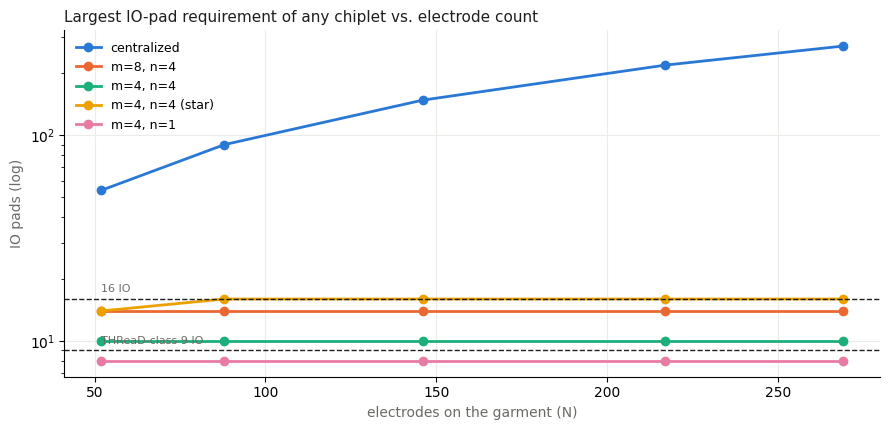

sensor_pads                    soc_pads                
N                       52  88   146  217  269      52  88  146 217 269
architecture                                                           
centralized              54  90  148  219  271        2   2   2   2   2
m=4, n=1                  6   6    6    6    6        8   8   8   8   8
m=4, n=4                 10  10   10   10   10        8   8   8   8   8
m=4, n=4 (star)           6   6    6    6    6       14  16  16  16  16
m=8, n=4                 14  14   14   14   14        8   8   8   8   8

In [2]:
rows = []
for pitch, d in L.items():
    for lbl, *_ in ARCH:
        pt = d['pts'][lbl]
        rows.append(dict(N=d['N'], architecture=lbl, sensor_pads=max(pt.node_pads), soc_pads=max(pt.soc_pads),
                         fits_9_IO=max(max(pt.node_pads), max(pt.soc_pads)) <= 9,
                         fits_16_IO=max(max(pt.node_pads), max(pt.soc_pads)) <= 16))
PADS = pd.DataFrame(rows)
fig, ax = plt.subplots(figsize=(9, 4.4))
for k, (lbl, *_) in enumerate(ARCH):
    sub = PADS[PADS.architecture == lbl]
    ax.plot(sub.N, np.maximum(sub.sensor_pads, sub.soc_pads), color=HUES[k], lw=2, marker='o', ms=6, label=lbl)
for b, t in [(9, 'THReaD-class 9 IO'), (16, '16 IO')]:
    ax.axhline(b, color=INK, lw=1, ls='--'); ax.text(L[PITCHES[0]]['N'], b * 1.08, t, fontsize=8, color=MUTED)
ax.set_yscale('log'); ax.legend(frameon=False, fontsize=9)
style(ax, 'Largest IO-pad requirement of any chiplet vs. electrode count', 'electrodes on the garment (N)', 'IO pads (log)')
plt.tight_layout(); plt.savefig('scaling_pads.png', dpi=160); plt.show()
PADS.pivot_table(index='architecture', columns='N', values=['sensor_pads', 'soc_pads'], aggfunc='first')

## Orchestrator memory for BSPM: store the window vs. stream (32 kB cap)

In [3]:
rows = []
for pitch, d in L.items():
    for lbl, *_ in ARCH:
        pt = d['pts'][lbl]
        for an in ['stream', 'store']:
            for T in [10, 60, 600]:
                if an == 'stream' and T != 60:
                    continue
                Lm = pw.mode_load(d['sites'], d['D'], pt, 'BSPM', pw.P(bspm_analysis=an, T_win_bspm=T))
                rows.append(dict(N=d['N'], architecture=lbl, analysis=f"{an}" + ("" if an == 'stream' else f" {T}s"),
                                 max_head_kB=round(max(Lm.head_mem_kB.values())), leads_onbody=f"{Lm.onbody_frac*100:.0f}%"))
MEM = pd.DataFrame(rows)
MEM.pivot_table(index=['architecture', 'analysis'], columns='N', values='max_head_kB', aggfunc='first')

N                             52     88     146     217     269
architecture    analysis                                       
centralized     store 10s     388    748   1328    2038    2558
                store 600s  22808  44408  79208  121808  153008
                store 60s    2288   4448   7928   12188   15308
                stream         65    119    206     312     390
m=4, n=1        store 10s      48     48     48      48      48
                store 600s   2408   2408   2408    2408    2408
                store 60s     248    248    248     248     248
                stream         14     14     14      14      14
m=4, n=4        store 10s     118    168    168     168     168
                store 600s   6608   9608   9608    9608    9608
                store 60s     668    968    968     968     968
                stream         24     32     32      32      32
m=4, n=4 (star) store 10s     118    168    168     168     168
                store 600s   6608   9608   9608    9608    9608
                store 60s     668    968    968     968     968
                stream         24     32     32      32      32
m=8, n=4        store 10s     198    328    328     328     328
                store 600s  11408  19208  19208   19208   19208
                store 60s    1148   1928   1928    1928    1928
                stream         36     56     56      56      56

## Power vs. electrode count: overnight mapping shirt (sleepBSPM, 60 s windows, streaming analysis)

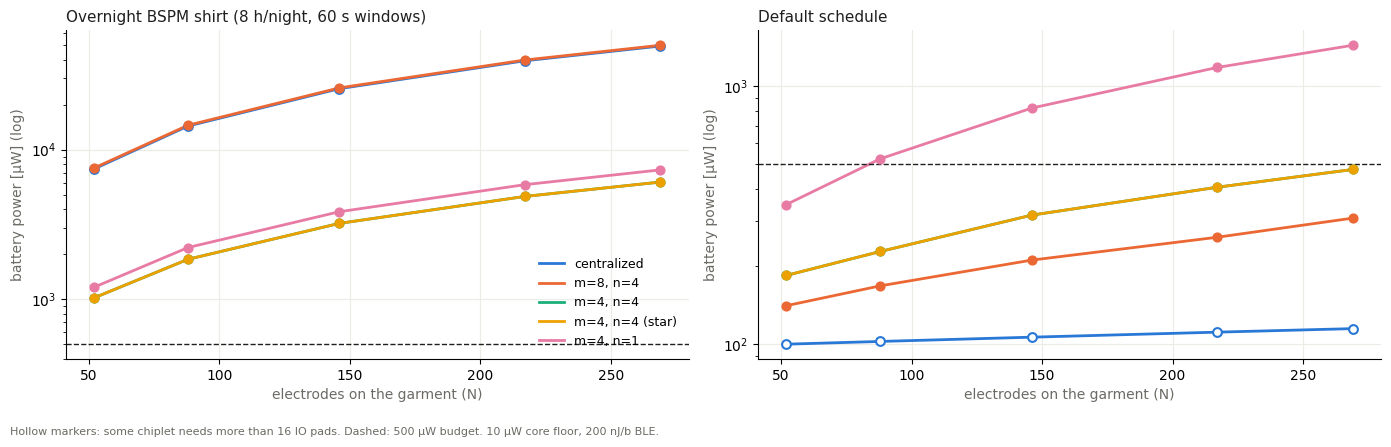

bspm_onbody                     sleepBSPM_uW                                        
N                       52   88   146  217  269          52        88        146       217       269
architecture                                                                                        
centralized             0.0  0.0  0.0  0.0  0.0      7427.59  14384.32  25592.40  39312.64  49361.26
m=4, n=1                1.0  1.0  1.0  1.0  1.0      1201.07   2214.23   3844.95   5831.87   7326.19
m=4, n=4                1.0  1.0  1.0  1.0  1.0      1019.90   1847.81   3213.06   4864.60   6072.65
m=4, n=4 (star)         1.0  1.0  1.0  1.0  1.0      1019.90   1847.81   3213.06   4864.60   6072.65
m=8, n=4                0.0  0.0  0.0  0.0  0.0      7534.79  14560.46  25895.78  39774.65  49937.16

In [4]:
rows = []
for pitch, d in L.items():
    for lbl, *_ in ARCH:
        pt = d['pts'][lbl]
        a = pw.average_power(d['sites'], d['D'], pt, pw.P(schedule='sleepBSPM', bspm_analysis='stream', T_win_bspm=60), 'spec', FLOOR)
        b = pw.average_power(d['sites'], d['D'], pt, pw.P(), 'spec', FLOOR)
        Lm = pw.mode_load(d['sites'], d['D'], pt, 'BSPM', pw.P(bspm_analysis='stream', T_win_bspm=60))
        pads_ok = max(max(pt.node_pads), max(pt.soc_pads)) <= 16
        rows.append(dict(N=d['N'], architecture=lbl, sleepBSPM_uW=a['total']*1e6, sleep_tx_uW=a['tx']*1e6,
                         default_uW=b['total']*1e6, bspm_onbody=Lm.onbody_frac, pads_ok_16=pads_ok))
PW = pd.DataFrame(rows); PW.to_csv('scaling_power.csv', index=False)
fig, axes = plt.subplots(1, 2, figsize=(14, 4.4))
for ax, col, title in [(axes[0], 'sleepBSPM_uW', 'Overnight BSPM shirt (8 h/night, 60 s windows)'), (axes[1], 'default_uW', 'Default schedule')]:
    for k, (lbl, *_) in enumerate(ARCH):
        sub = PW[PW.architecture == lbl]
        ax.plot(sub.N, sub[col], color=HUES[k], lw=2, label=lbl)
        ok = sub.pads_ok_16
        ax.scatter(sub.N[ok], sub[col][ok], color=HUES[k], s=40, zorder=3)
        ax.scatter(sub.N[~ok], sub[col][~ok], facecolor='white', edgecolor=HUES[k], s=40, zorder=3, lw=1.5)
    ax.axhline(p0['P_budget'] * 1e3, color=INK, lw=1, ls='--')
    ax.set_yscale('log'); style(ax, title, 'electrodes on the garment (N)', 'battery power [µW] (log)')
axes[0].legend(frameon=False, fontsize=9)
fig.text(0.01, 0.0, 'Hollow markers: some chiplet needs more than 16 IO pads. Dashed: 500 µW budget. 10 µW core floor, 200 nJ/b BLE.', fontsize=8, color=MUTED)
plt.tight_layout(rect=(0, 0.04, 1, 1)); plt.savefig('scaling_power.png', dpi=160); plt.show()
PW.pivot_table(index='architecture', columns='N', values=['sleepBSPM_uW', 'bspm_onbody'], aggfunc='first').round(2)

## Tunable windows: overnight BSPM vs. window length and output size (N ≈ 146, m = 4, n = 4)

In [5]:
d = L[5]; pt = d['pts']['m=4, n=4']; ptc = d['pts']['centralized']
rows = []
for T in [10, 60, 600]:
  for pab in [0.05, 0.0]:
    for tmpl in [0.6, 0.1]:
        r = dict(T_win_bspm_s=T, p_abnormal_bspm=pab, template_s=tmpl)
        for an in ['stream', 'store']:
            pp = pw.P(schedule='sleepBSPM', bspm_analysis=an, T_win_bspm=T, template_s_bspm=tmpl, p_abnormal_bspm=pab)
            r[f'm4n4_{an}_uW'] = round(pw.average_power(d['sites'], d['D'], pt, pp, 'spec', FLOOR)['total'] * 1e6)
            r[f'central_{an}_uW'] = round(pw.average_power(d['sites'], d['D'], ptc, pp, 'spec', FLOOR)['total'] * 1e6)
        rows.append(r)
pd.DataFrame(rows)

,T_win_bspm_s,p_abnormal_bspm,template_s,m4n4_stream_uW,central_stream_uW,m4n4_store_uW,central_store_uW
0,10,0.05,0.6,8250,25592,26130,25592
1,10,0.05,0.1,3213,25592,26130,25592
2,10,0.00,0.6,6991,25592,26130,25592
3,10,0.00,0.1,1954,25592,26130,25592
4,60,0.05,0.6,3213,25592,26130,25592
5,60,0.05,0.1,2374,25592,26130,25592
6,60,0.00,0.6,1954,25592,26130,25592
7,60,0.00,0.1,1114,25592,26130,25592
8,600,0.05,0.6,2306,25592,26130,25592
9,600,0.05,0.1,2223,25592,26130,25592


## Where the overnight power goes (N ≈ 146, m = 4, n = 4, streaming, 600 s windows, templates only)

In [6]:
pp = pw.P(schedule='sleepBSPM', bspm_analysis='stream', T_win_bspm=600, template_s_bspm=0.1, p_abnormal_bspm=0.0)
mp = pw.mode_power(d['sites'], d['D'], pt, 'BSPM', pp, 'spec', FLOOR)
print('during mapping (delivered, uW):', {k: round(v * 1e6) for k, v in mp.items()})
rows = []
for afe in [5, 2, 1, 0.5]:
    for nf in [10, 5, 2]:
        a = pw.average_power(d['sites'], d['D'], pt, dict(pp, P_afe_diag=afe, P_node_fixed=nf), 'spec', FLOOR)
        rows.append(dict(P_afe_uW_ch=afe, P_node_fixed_uW=nf, battery_avg_uW=round(a['total'] * 1e6)))
pd.DataFrame(rows).pivot_table(index='P_afe_uW_ch', columns='P_node_fixed_uW', values='battery_avg_uW')

during mapping (delivered, uW): {'afe_adc': 687, 'node_fixed': 444, 'node_off': 0, 'link_intra': 113, 'link_inter': 71, 'orch_floor': 132, 'orch_compute': 101, 'tx': 55}


P_node_fixed_uW,2,5,10
P_afe_uW_ch,,,
0.5,516.0,574.0,672.0
1.0,548.0,607.0,704.0
2.0,613.0,671.0,769.0
5.0,807.0,866.0,963.0


## Findings (ML layout + spares, grid pitch 10 → 3.5 cm, 52 → 269 electrodes)

1. **Pads make a centralized textile chiplet physically impossible beyond a handful of electrodes.**
   * One chiplet terminating every electrode needs N + 2 IO pads: 54 to 271 here, against about 9 (THReaD) to 16 for realistic direct-die-attach chiplets.
   * Distributed designs need a constant number of pads, independent of N:
     | Design | Sensor chiplet pads | Orchestrator pads |
     |---|---|---|
     | m = 4, mesh | 10 | 8 |
     | m = 4, n = 1 | 6 | 8 |
     | m = 8, mesh | 14 | 8 |
     | m = 4, star into a head | 6 | 16 |
   * **Spec rule:** sensor-chiplet IO ≥ m + 2·(link ports), and orchestrator IO ≥ 2·(link ports). A THReaD-class 9-IO die is one pad short for a 4-electrode mesh node. The options are 10 or more IO, a lower mesh degree, or m ≤ 1 in a full mesh.
2. **Memory: storing BSPM is infeasible everywhere; streaming works only when distributed.**
   * Storing even a 10 s BSPM window needs 388–2,558 kB on a centralized chip and 168 kB per head at m = 4, n = 4.
   * Streaming analysis (about 1.5 kB per lead) needs 65–390 kB centralized, **growing with N**. At m = 4, n = 4 it needs 32 kB per head, **constant in N**, and just fits a 32 kB chiplet. At m = 8, n = 4 it needs 56 kB and doesn't fit.
   * So on-garment BSPM needs streaming analysis **and** at most about 16 leads per 32 kB orchestrator.
3. **An overnight mapping shirt is where distribution is mandatory.** With 8 h/night of BSPM and 60 s windows:
   * centralized has to stream: 7.4 mW at 52 electrodes, rising to 49 mW at 269;
   * m = 4, n = 4 analyses on-body: 1.0–6.1 mW, about **7–8× lower**;
   * with 600 s windows and short (0.1 s) templates only, it is about 0.96 mW at N ≈ 146.
4. **What's left after that is acquisition, and that sets the chiplet spec.** During mapping at N ≈ 146, AFE is about 690 µW, sensor-node overhead about 440 µW, links about 185 µW and orchestrators about 230 µW. Closing the 500 µW, 7-day budget needs AFE ≤ about 0.5 µW/ch **and** node overhead ≤ about 2 µW (516 µW in this sweep). That is about 10× below today's diagnostic-grade figure, and it doesn't count nightly recharging, which would relax it.
5. **Windows are tunable, and longer is cheaper overnight.**
   * Once analysis streams, memory no longer depends on the window, and TX per hour falls as the window grows (one template per window).
   * Going from 10 s to 600 s cuts overnight power from about 7.0 to 1.0 mW (0.6 s templates, no full captures).
   * Sending full abnormal captures (p_abnormal_bspm = 5%) adds 1–2 mW at long windows. For BSPM, the export policy matters more than the window.
6. **Idle chiplets cost power as the garment grows, even in the default schedule.** Most nodes are off most of the time, but their off-state leakage and the orchestrator floors scale with N:
   * m = 4, n = 4 rises from 185 to 475 µW (52 → 269 electrodes);
   * m = 4, n = 1 passes the 500 µW budget at about 90 electrodes;
   * m = 8, n = 4 rises from 141 to 308 µW;
   * centralized stays at about 100–115 µW, but is pad-infeasible (hollow markers).

   At high N, the binding spec items are orchestrator floor × number of SoCs and sensor off-state power, not active power.
7. **Plot note:** some lines overlap. Centralized and m = 8, n = 4 overlap in the overnight panel, because both fall back to streaming. m = 4, n = 4 mesh and star have identical power in both panels; they differ only in pads.
